<div style="font-family:'Times New Roman';">

**TEMARIO**

**1. Cuantificación sin etiquetas (LFQ)**

Procesamiento de datos y control de calidad

Pruebas estadísticas

Comparación del resumen robusto y maxLFQ con las abundancias a nivel de proteína

Una normalización alternativa que utiliza una expectativa previa

**2. Etiquetas de masa en tándem (TMT)**

Procesamiento de datos y control de calidad

Pruebas estadísticas

**3. Marcaje de isótopos estables con/por aminoácidos en cultivos celulares (SILAC)**
Procesamiento de datos y control de calidad

Pruebas estadísticas

Prueba de tasa de incorporación

Materiales ampliados

Fosfoproteómica utilizando TMT

Pruebas estadísticas de fosfoproteómica

<div style="font-family:'Times New Roman';">

**Proteómica de cuantificación sin etiquetas**

Preámbulo

Datos de entrada

Analizar el archivo PeptideGroups.txt

Convertir a MSnSet

Péptidos de control de calidad

Valores faltantes

Normalizar las intensidades de los péptidos

Resumiendo la abundancia a nivel de proteínas

Resumiendo la abundancia a nivel de proteínas

Secciones adicionales opcionales sobre normalización y resumen

**Preámbulo**

La cuantificación sin etiquetas (LFQ) es la forma más simple de proteómica cuantitativa, en la que se cuantifican diferentes muestras en ejecuciones de MS separadas.

Dado que cada muestra se analiza por separado, se cuantificarán diferentes péptidos en cada una y las intensidades peptídicas podrían no ser directamente comparables entre muestras. Una solución a la mayor carga de valores faltantes es la "coincidencia entre análisis" (Cox et al., 2014) , o el algoritmo funcionalmente equivalente "Minora", empleado por Proteome Discoverer (PD). Estos algoritmos utilizan los tiempos de retención observados de los iones MS1 que se emparejaron espectralmente correctamente en una muestra para identificar la probable secuencia peptídica de los iones MS1 que no se pudo emparejar espectralmente en otra muestra.

A pesar de los inconvenientes del LFQ, el análisis de datos sigue siendo relativamente sencillo, aunque hay pasos que requieren una cuidadosa consideración y una evaluación de control de calidad.

Dependencias de carga
Cargue las bibliotecas necesarias.





<div style="font-family:'Times New Roman';">

**Materiales del curso**

La primera parte del curso se divide en secciones para diferentes variantes de la proteómica cuantitativa ascendente por espectrometría de masas. Cada sección contiene una subsección que abarca:

1. Procesamiento de datos y control de calidad que comienza con los archivos de salida de Proteome Discoverer (PD) y realiza el filtrado, el control de calidad y el procesamiento de datos para obtener los datos de cuantificación.

2. Pruebas estadísticas de abundancia diferencial

Se incluyen subsecciones adicionales para cubrir más temas.

Además de la parte principal del curso, hay materiales ampliados para cubrir:

Fosfoproteómica mediante etiquetas de masa en tándem

In [3]:
# instalar los paquetes necesarios

remotes::install_github("MRCToxBioinformatics/Proteomics_data_analysis", build_vignettes = TRUE, dependencies = TRUE)
remotes::install_github("CambridgeCentreForProteomics/camprotR", dependencies = TRUE)

if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("biobroom")

library(ggplot2)
library(MSnbase)
library(biobroom)
library(camprotR)
library(Proteomics.analysis.data)
library(dplyr)
library(tidyr)

Skipping install of 'Proteomics.data.analysis' from a github remote, the SHA1 (fb02d8f4) has not changed since last install.
  Use `force = TRUE` to force installation

Skipping install of 'camprotR' from a github remote, the SHA1 (197a4468) has not changed since last install.
  Use `force = TRUE` to force installation

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'biobroom'"
Cargando paquete requerido: BiocGenerics

Cargando paquete requerido: generics


Adjuntando el paquete: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Adjun

<div style="font-family:'Times New Roman';">

**Datos de entrada**

Comenzamos con el resultado de PD a nivel de péptidos. Recomendamos comenzar con el resultado de PD a nivel de péptidos para los datos LFQ, ya que esto permitirá realizar un control de calidad a nivel de péptidos y luego resumir la abundancia a nivel de proteína de una manera más adecuada que la que PD utiliza por defecto, que consiste simplemente en sumar todos los PSM que pasan los filtros.

Los datos que utilizamos provienen de un experimento diseñado para identificar proteínas de unión a ARN (RBP) en la línea celular U-2 OS mediante el método OOPS (Queiroz et al., 2019) . Se utiliza una comparación de RNasa +/- para separar las RBP de las proteínas no específicas de fondo. Se realizaron cuatro experimentos replicados, con los experimentos de RNasa +/- realizados desde la misma interfaz OOPS. Para cada ejecución de LFQ, se inyectó aproximadamente la misma cantidad de péptidos, con base en la cuantificación de la concentración de péptidos después de la digestión con tripsina. Estos datos no se han publicado, pero el objetivo del experimento es equivalente a la Figura 2e en el artículo original de OOPS.

Los datos que utilizaremos están disponibles a través del Proteomics.analysis.datapaquete.

<div style="font-family:'Times New Roman';">

Podemos explorar la estructura de los datos de entrada usando str. Vemos que tenemos un data.framecon 7808 filas y 41 columnas. Las columnas más importantes para nosotros son:

Secuencia : La secuencia del péptido

Modificaciones : Las modificaciones de péptidos detectadas, incluidas las variables, por ejemplo, modificaciones inducidas como la oxidación

Master.Protein.Accessions : Las proteínas maestras asignadas

Abundancia.F*.Muestra : Columnas con las intensidades de los péptidos

In [10]:
pep_data <- read.delim(
  system.file("extdata", 'OOPS_RNase_LFQ', 'LFQ_OOPS_RNase_PeptideGroups.txt',
              package = "Proteomics.analysis.data"))

str(pep_data)

'data.frame':	7808 obs. of  41 variables:
 $ Peptide.Groups.Peptide.Group.ID                      : int  3 103128 103062 103059 103056 103049 103048 103045 102936 102916 ...
 $ Checked                                              : chr  "False" "False" "False" "False" ...
 $ Confidence                                           : chr  "High" "High" "High" "High" ...
 $ Sequence                                             : chr  "AAAAAAAAAAAAAAAGAGAGAK" "LVKPGNQNTQVTEAWNK" "LVGSVNLFSDENVPR" "LVGSQEELASWGHEYVR" ...
 $ Modifications                                        : chr  "" "" "" "" ...
 $ Qvality.PEP                                          : num  4.27e-07 8.31e-04 1.36e-03 7.92e-04 1.87e-06 ...
 $ Qvality.q.value                                      : num  0.00026 0.00026 0.00026 0.00026 0.00026 ...
 $ Number.of.Protein.Groups                             : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number.of.Proteins                                   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Number.

<div style="font-family:'Times New Roman';">

El InputFiles.txt archivo de PD puede utilizarse para determinar la relación entre las columnas Abundance.F*.Sample y las muestras. Si tiene alguna duda, también puede consultar con el Centro de Proteómica.

El archivo adjunto LFQ_OOPS_RNase_InputFiles.txt también está disponible a través del Proteomics.analysis.data paquete.

In [11]:
inputfiles <- read.delim(
  system.file("extdata", 'OOPS_RNase_LFQ', 'LFQ_OOPS_RNase_InputFiles.txt',
              package = "Proteomics.analysis.data"))
print(inputfiles %>% filter(Study.File.ID!=''))

  Input.Files.Workflow.ID Input.Files.Workflow.Level Input.Files. Study.File.ID
1                    -177                          1           55           F17
2                    -180                          1           40           F18
3                    -183                          1           42           F19
4                    -186                          1           44           F20
5                    -189                          1           46           F21
6                    -192                          1           48           F22
7                    -195                          1           50           F23
8                    -198                          1           52           F24
                                                               File.Name
1      Z:\\RAW\\rq214\\LFQ_RNase_test_Jan2020\\R_neg_MetChloroform_1.raw
2      Z:\\RAW\\rq214\\LFQ_RNase_test_Jan2020\\R_neg_MetChloroform_2.raw
3      Z:\\RAW\\rq214\\LFQ_RNase_test_Jan2020\\R_neg_MetChlor

<div style="font-family:'Times New Roman';">

Aquí, vemos que F17-20 son 'R_neg', p. ej., RNasa -, y F21-24 son 'R_positivos', p. ej., RNasa +.

Podríamos analizar el InputFiles.txtarchivo para generar la información de muestra, pero para este experimento, es lo suficientemente pequeño como para que pueda generarse fácilmente de forma manual.



In [13]:
sample_data <- data.frame(
  File = paste0("F", 17:24),
  Sample = paste0(rep(c("RNase_neg", "RNase_pos"), each = 4), ".", 1:4),
  Condition = rep(c("RNase_neg", "RNase_pos"), each = 4),
  Replicate = rep(1:4, 2)
)

# Displaying the table in a nicer format
knitr::kable(sample_data,
             align = "cccc",
             format = "html",
             table.attr = "style='width:30%;'")
             
print(sample_data, row.names = FALSE)

<table style='width:30%;'>
 <thead>
  <tr>
   <th style="text-align:center;"> File </th>
   <th style="text-align:center;"> Sample </th>
   <th style="text-align:center;"> Condition </th>
   <th style="text-align:center;"> Replicate </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:center;"> F17 </td>
   <td style="text-align:center;"> RNase_neg.1 </td>
   <td style="text-align:center;"> RNase_neg </td>
   <td style="text-align:center;"> 1 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> F18 </td>
   <td style="text-align:center;"> RNase_neg.2 </td>
   <td style="text-align:center;"> RNase_neg </td>
   <td style="text-align:center;"> 2 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> F19 </td>
   <td style="text-align:center;"> RNase_neg.3 </td>
   <td style="text-align:center;"> RNase_neg </td>
   <td style="text-align:center;"> 3 </td>
  </tr>
  <tr>
   <td style="text-align:center;"> F20 </td>
   <td style="text-align:center;"> RNase_neg.4 </td>
   <td st

 File      Sample Condition Replicate
  F17 RNase_neg.1 RNase_neg         1
  F18 RNase_neg.2 RNase_neg         2
  F19 RNase_neg.3 RNase_neg         3
  F20 RNase_neg.4 RNase_neg         4
  F21 RNase_pos.1 RNase_pos         1
  F22 RNase_pos.2 RNase_pos         2
  F23 RNase_pos.3 RNase_pos         3
  F24 RNase_pos.4 RNase_pos         4


<div style="font-family:'Times New Roman';">

**Analizar el archivo PeptideGroups.txt**

Para simplificar la lectura de los datos y el filtrado inicial, utilizaremos camprotR::parse_features. Esta función leerá los datos y eliminará las proteínas y características contaminantes sin datos de cuantificación. Las proteínas contaminantes se definieron utilizando la base de datos cRAP y se proporcionaron a PD. Necesitamos obtener sus accesiones y proporcionarlas a camprotR::parse_features. A continuación, analizamos el archivo FASTA de cRAP para extraer los identificadores de las proteínas cRAP, tanto en formato 'cRAP' como en los identificadores Uniprot correspondientes.

El archivo que utilizaremos, cRAP_20190401.fasta.gz, está nuevamente disponible a través del Proteomics.analysis.datapaquete.



In [14]:
crap_fasta_inf <- system.file(
  "extdata", "cRAP_20190401.fasta.gz",
  package = "Proteomics.analysis.data"
)

# Load the cRAP FASTA used for the PD search
crap_fasta <- Biostrings::fasta.index(crap_fasta_inf, seqtype = "AA")

# Extract the UniProt accessions associated with each cRAP protein
crap_accessions <- crap_fasta %>%
  pull(desc) %>%
  stringr::str_extract_all(pattern="(?<=\\|).*?(?=\\|)") %>%
  unlist()

<div style="font-family:'Times New Roman';">

Luego podemos suministrar estos identificadores de proteína cRAP que camprotR::parse_features() eliminarán características (es decir, péptidos en este caso) que pueden originarse a partir de contaminantes, así como características que no tienen una proteína maestra única.

Consulte ?parse_featurespara obtener más detalles, incluida la eliminación de 'cRAP asociado' para la eliminación conservadora de contaminantes.



In [15]:
pep_data_flt <- camprotR::parse_features(
  pep_data,
  level = 'peptide',
  crap_proteins = crap_accessions,
)

Parsing features...

7808 features found from 1463 master proteins => Input

242 cRAP proteins supplied

364 proteins identified as 'cRAP associated'

7509 features found from 1414 master proteins => cRAP features removed

7476 features found from 1396 master proteins => associated cRAP features removed

7471 features found from 1395 master proteins => features without a master protein removed

7250 features found from 1307 master proteins => features with non-unique master proteins removed



<div style="font-family:'Times New Roman';">

De lo anterior, podemos ver que comenzamos con 7808 "características" (péptidos) de 1463 proteínas maestras en todas las muestras. Tras eliminar los contaminantes y los péptidos que no se pueden asignar a una proteína maestra única, nos quedan 7250 péptidos de 1307 proteínas maestras.



<div style="font-family:'Times New Roman';">

**Convertir a MSnSet**

Ahora almacenamos los datos de péptidos filtrados en un MSnSet, el objeto de datos estándar para la proteómica en R.

Este objeto contiene 3 elementos:

1. Una matriz de datos de cuantificación (filas=características, p. ej., péptidos/proteínas, columnas=muestras)

2. Datos de características (filas=características, columnas=anotaciones de características, p. ej. asignación de proteína maestra de péptidos)

3. Detalles experimentales (filas=muestras, columnas=detalles experimentales, p. ej. tratamiento)

vignette("msnset", package="camprotR")Para más detalles, consulte la página 10 .



In [16]:
# Create expression matrix with peptide abundances (exprs) and
# human readable column names
exprs_data <- pep_data_flt %>%
  select(matches("Abundance")) %>%
  setNames(sample_data$Sample) %>%
  as.matrix()

# Create data.frame with sample metadata (pData)
pheno_data <- sample_data %>%
  select(-File) %>%
  tibble::column_to_rownames(var = "Sample")

# Create data.frame with peptide metadata (fData)
feature_data <- pep_data_flt %>%
  select(-matches("Abundance"))

# Create MSnSet
pep <- MSnbase::MSnSet(exprs = exprs_data,
                       fData = feature_data,
                       pData = pheno_data)

<div style="font-family:'Times New Roman';">

**Péptidos de control de calidad**

En primer lugar, queremos inspeccionar las distribuciones de intensidad de los péptidos.

**Ejercicio 1:**

Grafique las distribuciones de intensidades para cada muestra. ¿Qué concluye?

Consejos:

Puede acceder a los datos del ensayo utilizandoexprs(pep)

Necesitarás transformar logarítmicamente las abundancias para que sean interpretables.

Solución

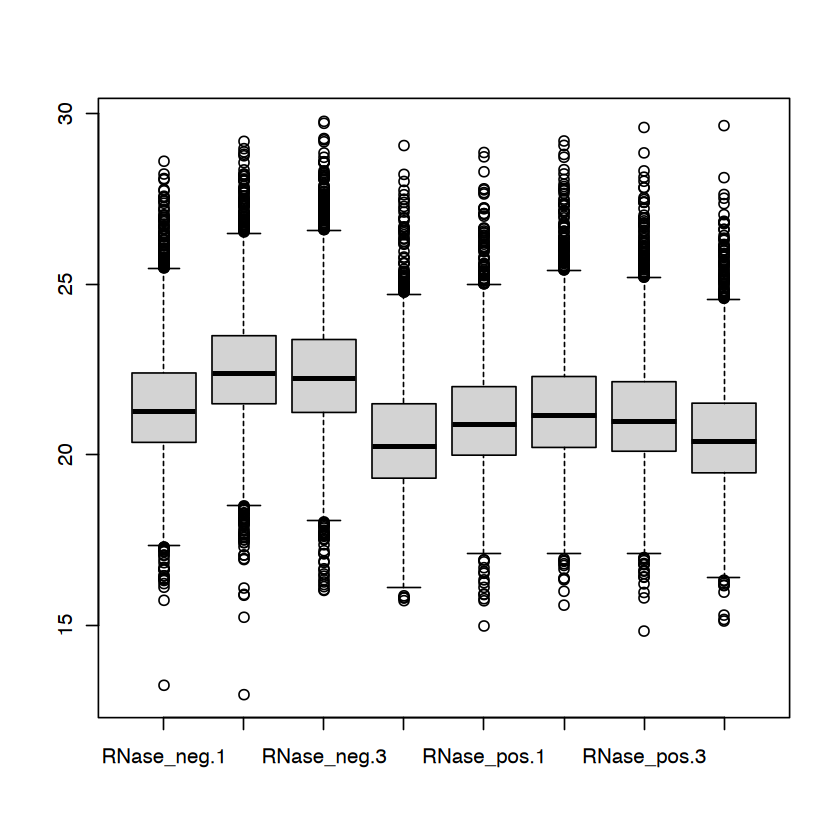

In [17]:
log(pep, base=2) %>% exprs() %>% boxplot()

<div style="font-family:'Times New Roman';">

El código anterior nos da una representación básica. Podríamos mejorarla, pero camprotRya cuenta con una función para explorar las distribuciones de cuantificación, plot_quantque podemos usar en su lugar. A continuación, trazamos diagramas de caja y de densidad para inspeccionar las distribuciones de abundancia.

Warning message:
"Removed 19289 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


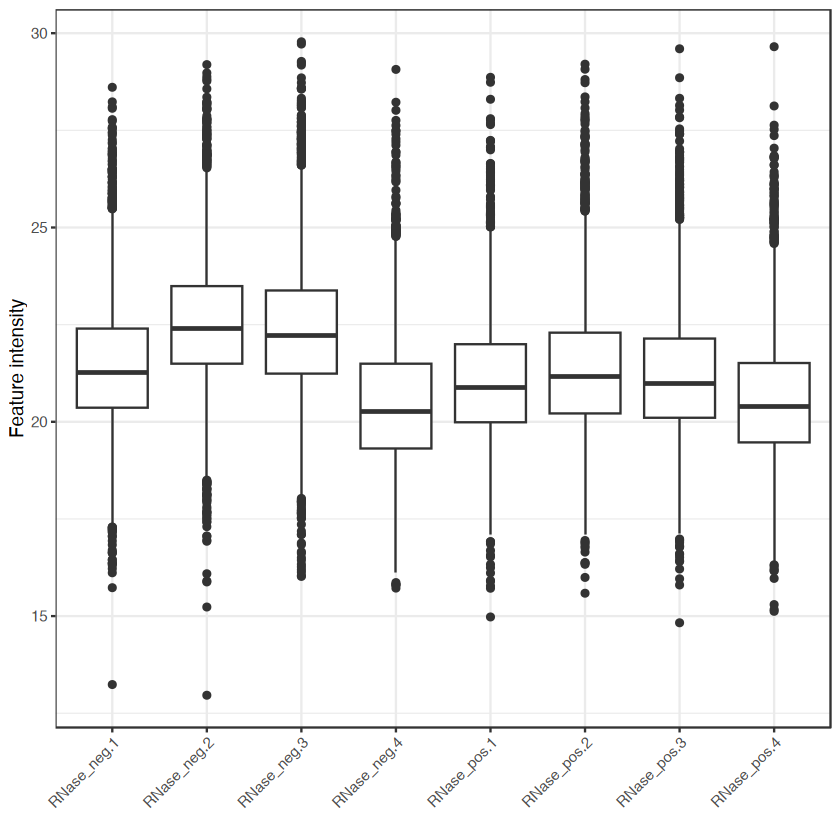

In [18]:
pep %>%
  log(base = 2) %>%
  camprotR::plot_quant(method = 'box')

<div style="font-family:'Times New Roman';">

Intensidades de péptidos

Warning message:
"Removed 19289 rows containing non-finite outside the scale range
(`stat_density()`)."


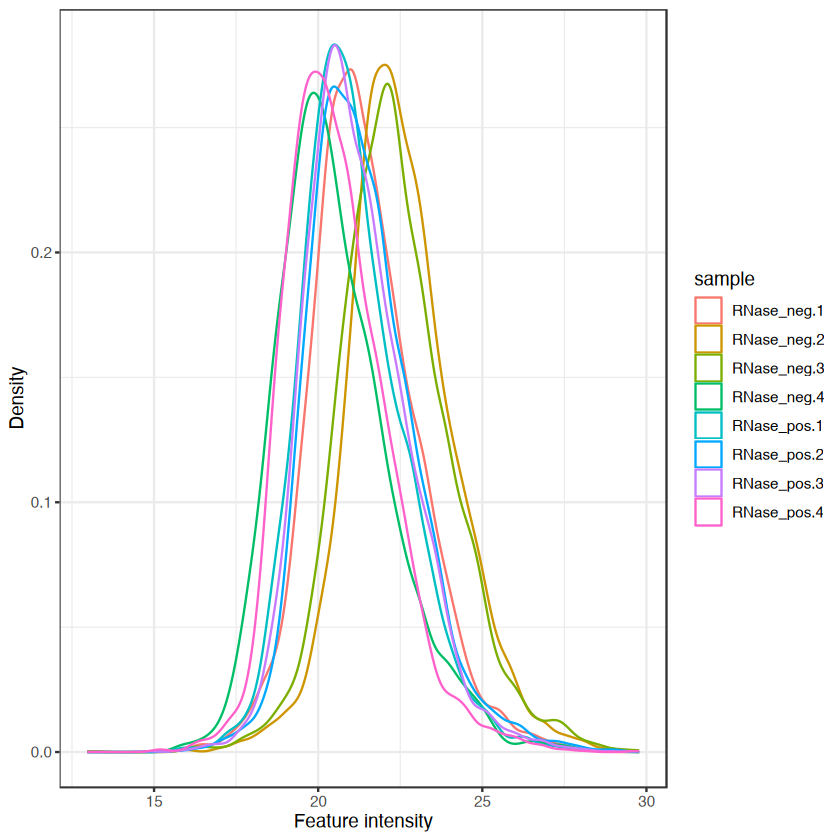

In [19]:
pep %>%
  log(base = 2) %>%
  camprotR::plot_quant(method = 'density')


<div style="font-family:'Times New Roman';">

Intensidades de péptidos

Esperamos que sean aproximadamente iguales, y cualquier muestra con una intensidad muy baja sería preocupante y requeriría mayor investigación. En este caso, se observa una clara variabilidad, pero ninguna muestra con una intensidad muy baja.

<div style="font-family:'Times New Roman';">

**Valores faltantes**

A continuación, consideramos los valores faltantes, utilizando MSnbase::plotNApara obtener una visión gráfica rápida. Esta función muestra el número de características con cada nivel de integridad de los datos («Características individuales») y la proporción general de valores faltantes en el conjunto de datos (Conjunto de datos completo). El número de características con un nivel aceptable de valores faltantes (especificado por pNA) también se resalta en el gráfico.

Tenga en cuenta que MSnbase::plotNAse asume que el objeto contiene datos a nivel de proteína y se asigna el nombre correspondiente al eje x. Aquí, actualizamos la estética del gráfico y renombramos el eje x.

Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
i Please use the `linewidth` argument instead.
i The deprecated feature was likely used in the MSnbase package.
  Please report the issue at <https://github.com/lgatto/MSnbase/issues>."


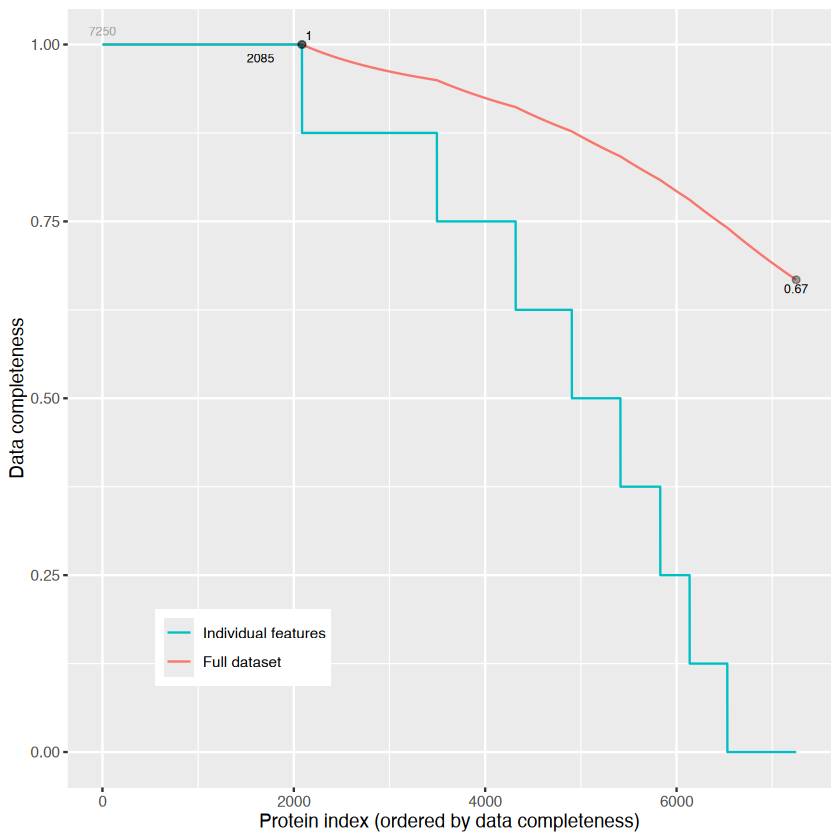

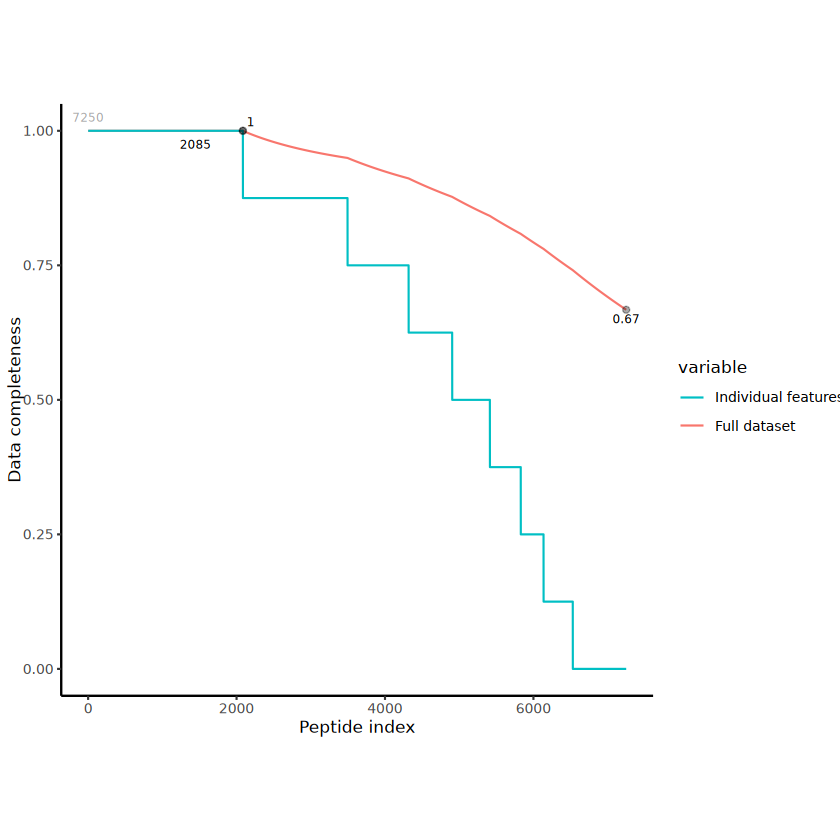

In [20]:
p <- MSnbase::plotNA(pep, pNA = 0) +
  camprotR::theme_camprot(border = FALSE, base_family = 'sans', base_size = 10) +
  labs(x = 'Peptide index')

print(p)

**Integridad de los datos a nivel de péptidos**

Ejercicio 2

Hemos estado acostumbrados MSnbase::plotNAa evaluar los valores faltantes, pero es sencillo hacerlo nosotros mismos directamente desde el prot_resobjeto.

1. ¿Cuántos valores faltan en total?

2. ¿Qué fracción de valores faltan?

3. ¿Cuántos valores faltantes hay en cada muestra?

4. ¿Cuántos péptidos no tienen valores faltantes?

Sugerencia: Puedes usarlo is.nadirectamente en el MSnSety es equivalente a llamar is.na(exprs(obj))

Solución

In [21]:

sum(is.na(pep)) #1
#> [1] 19289
mean(is.na(pep)) #2
#> [1] 0.332569
colSums(is.na(pep)) #3
#> RNase_neg.1 RNase_neg.2 RNase_neg.3 RNase_neg.4 RNase_pos.1 RNase_pos.2 
#>        1901        2001        1897        3542        2580        2504 
#> RNase_pos.3 RNase_pos.4 
#>        2098        2766
sum(rowSums(is.na(pep))==0) #4
#> [1] 2085

[1] 19289

[1] 0.332569

RNase_neg.1 RNase_neg.2 RNase_neg.3 RNase_neg.4 RNase_pos.1 RNase_pos.2 
       1901        2001        1897        3542        2580        2504 
RNase_pos.3 RNase_pos.4 
       2098        2766

[1] 2085

<div style="font-family:'Times New Roman';">

Así pues, de los 7250 péptidos, solo 2085 presentan valores de cuantificación en las 8 muestras. Esto no es sorprendente para LFQ, ya que cada muestra se prepara y se analiza por separado.

También podemos explorar la estructura de los valores faltantes con más detalle mediante un gráfico de "alteraciones". En este caso, utilizamos el naniarpaquete.

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information.
i The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
i The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
i Please use the `linewidth` argument instead.
i The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors."


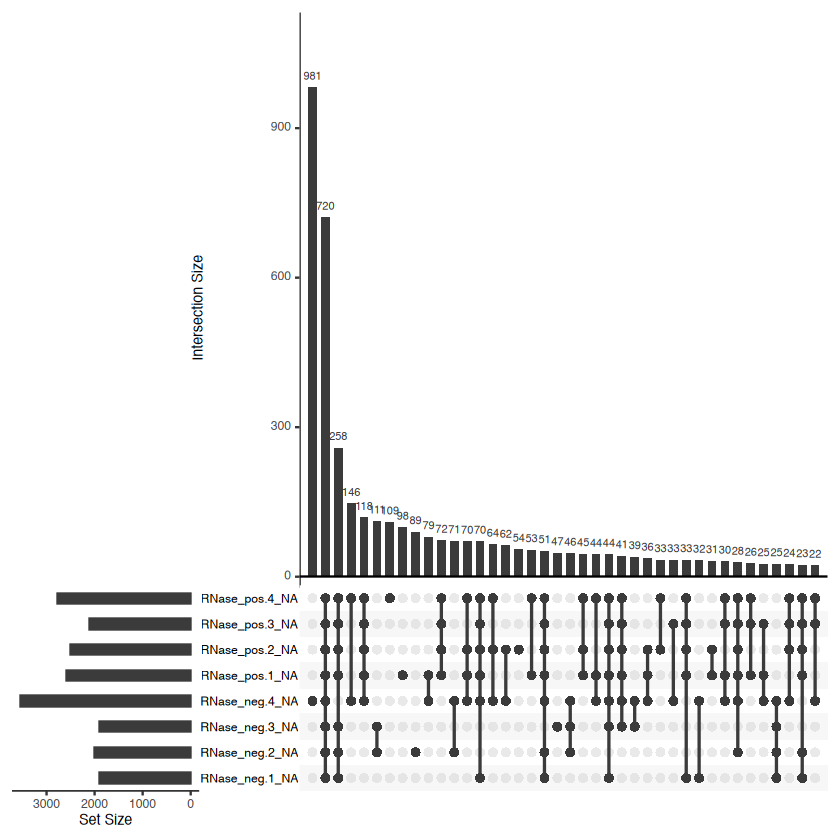

In [22]:
missing_data <- pep %>%
  exprs() %>%
  data.frame()

naniar::gg_miss_upset(missing_data,
                      sets = paste0(colnames(pep), '_NA'),
                      keep.order = TRUE,
                      nsets = 10)


<div style="font-family:'Times New Roman';">

Los valores faltantes alteran la gráfica

Entonces, en este caso, podemos ver que los patrones de valores faltantes más comunes son:

1. Falta solo en la réplica 4 de ARNasa negativa
2. Falta en todas las muestras.
3. Falta en todas las demás muestras, excepto en la réplica 4 de ARNasa negativa

La réplica 4 de ARNasa negativa presentó intensidades peptídicas generales ligeramente inferiores y parece ser un caso atípico. En este caso, conservaremos la muestra, pero en otros casos, esto podría justificar una exploración más exhaustiva y, potencialmente, la eliminación de una muestra.



<div style="font-family:'Times New Roman';">

**Normalizar las intensidades de los péptidos**

No disponemos de proteínas de referencia internas con las que podamos normalizar, por lo que solo podremos evaluar la abundancia de proteínas en relación con la proteína presente en cada muestra. 

Dado que inyectamos la misma cantidad de péptidos en cada muestra, podría pensar que no debería haber razón para normalizar, ya que hacerlo conlleva el riesgo de eliminar la verdadera varianza biológica.



<div style="font-family:'Times New Roman';">

Las explicaciones técnicas son convincentes. Además, solo podemos evaluar la cuantificación relativa, dado que se desconocen las pérdidas de material en el procesamiento de las muestras. Por lo tanto, es razonable normalizar las abundancias.

Aquí aplicaremos la normalización de la mediana de modo que las medianas de todas las columnas (muestras) coincidan con la mediana general. En MSnbase::normalise, esto se denomina diff.median. Dado que las intensidades de los péptidos tienen una distribución logarítmica-gaussiana, las transformamos en logaritmos ² antes de realizar la normalización.

La normalización de la mediana es una forma relativamente simple de normalización, ya que solo aplicamos una transformación con un único factor de corrección para cada muestra. Esto es más probable que sea apropiado cuando las muestras que se comparan son similares entre sí. Podría decirse que, en este caso, nuestras muestras son más distintas, ya que comparamos muestras OOPS +/- RNasa, y podríamos al menos explorar el uso de una normalización más sofisticada, como la Normalización Estabilizadora de la Varianza (VSN). Para una discusión más completa sobre la normalización proteómica, véase (Välikangas, Suomi y Elo 2018) . Sin embargo, tenga en cuenta que este artículo aplica las normalizaciones a las abundancias a nivel de proteína.



Warning message:
"Removed 19289 rows containing non-finite outside the scale range
(`stat_density()`)."


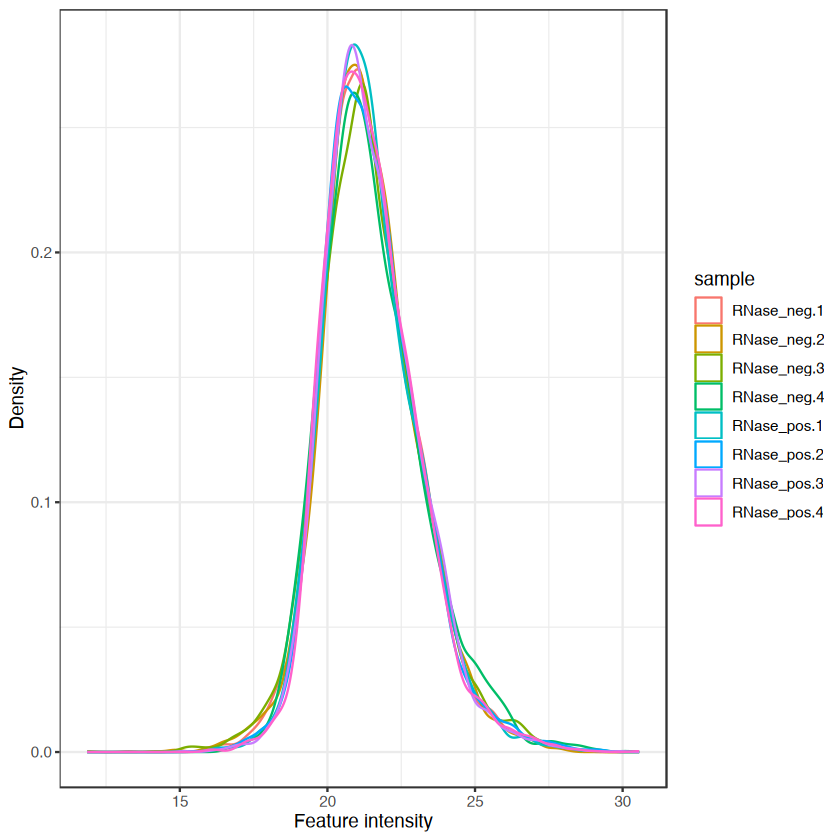

In [23]:
pep_norm <- pep %>%
  log(base = 2) %>%
  MSnbase::normalise('diff.median')  

pep_norm %>%
  camprotR::plot_quant(method = 'density')

<div style="font-family:'Times New Roman';">

Intensidades de proteínas después de la normalización



<div style="font-family:'Times New Roman';">

**Resumiendo la abundancia a nivel de proteínas**

Antes de poder resumir las abundancias a nivel de proteína, debemos excluir los péptidos con demasiados valores faltantes. En este caso, los péptidos con más de 4/8 valores faltantes se descartan mediante MSnbase::filterNA(). También debemos eliminar las proteínas sin al menos tres péptidos. Usaremos , camprotR::restrict_features_per_protein()que reemplazará los valores de cuantificación por NAsi la muestra no tiene dos péptidos cuantificados para una proteína determinada. Tenga en cuenta que esto significa que debemos repetir el proceso de filtrado, ya que estamos añadiendo valores faltantes.

In [24]:
pep_restricted <- pep_norm %>%
  # Maximum 4/8 missing values
  MSnbase::filterNA(pNA = 4/8) %>%

  # At least two peptides per protein
  camprotR::restrict_features_per_protein(min_features = 3, plot = FALSE) %>%

  # Repeat the filtering since restrict_features_per_protein will replace some values with NA
  MSnbase::filterNA(pNA = 4/8) %>%

  camprotR::restrict_features_per_protein(min_features = 3, plot = FALSE)

<div style="font-family:'Times New Roman';">

Luego podemos volver a inspeccionar los valores faltantes. Observe que hemos reducido el número total de péptidos a 4570.



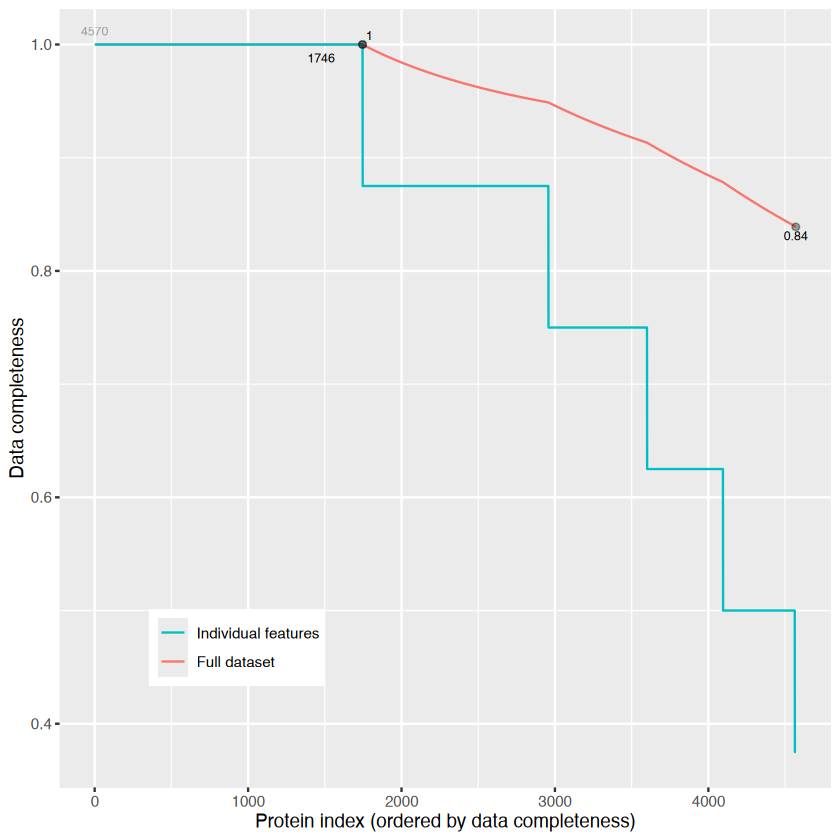

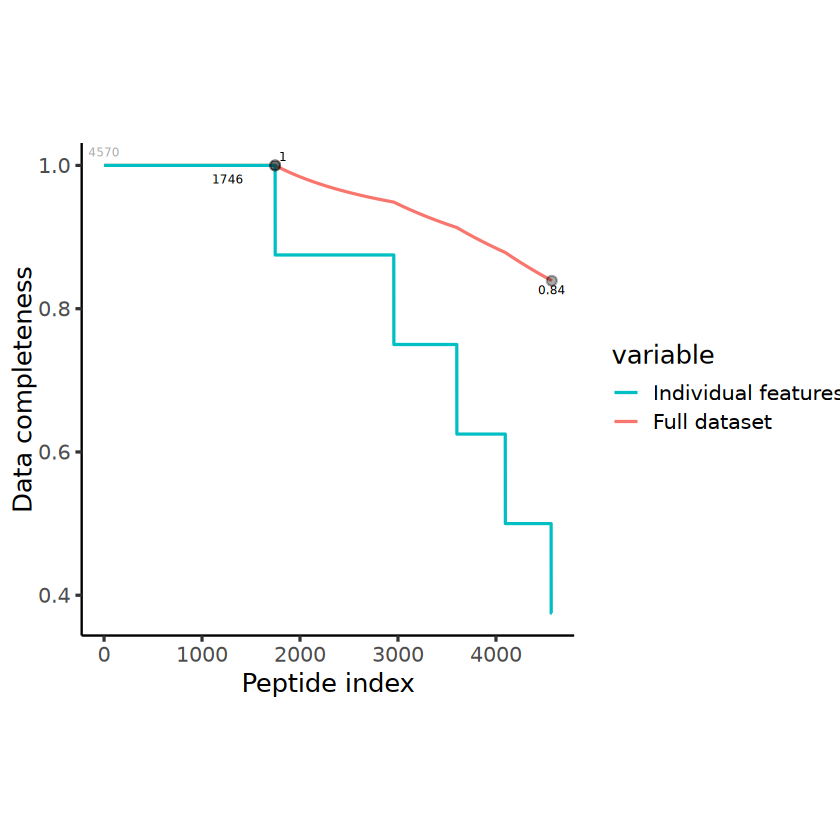

In [25]:
p <- MSnbase::plotNA(pep_restricted, pNA = 0) +
  camprotR::theme_camprot(border = FALSE, base_family = 'sans', base_size = 15) +
  labs(x = 'Peptide index')

print(p)

<div style="font-family:'Times New Roman';">

**Resumiendo la abundancia a nivel de proteínas**

Ahora podemos resumir la abundancia a nivel de proteína. A continuación, utilizamos el resumen robusto (Sticker et al., 2020) con MSnbase::combineFeatures(). Esto devuelve una advertencia sobre valores faltantes que podemos ignorar, ya que el método robusto está diseñado para gestionar valores faltantes. Consulte MsCoreUtils::robustSummary()esta publicación para obtener más información sobre el método robusto.

In [26]:
prot_robust <- pep_restricted %>%
  MSnbase::combineFeatures(
    # group the peptides by their master protein id
    groupBy = fData(pep_restricted)$Master.Protein.Accessions,
    method = 'robust',
    maxit = 1000  # Ensures convergence for MASS::rlm
  )


Your data contains missing values. Please read the relevant section in
the combineFeatures manual page for details on the effects of missing
values on data aggregation.



<div style="font-family:'Times New Roman';">

Podemos entonces volver a inspeccionar los valores faltantes a nivel de proteína. Así, tenemos cuantificación para 505 proteínas, de las cuales 288 están completamente cuantificadas en las 8 muestras. El patrón de valores faltantes más común permanece ausente solo en la réplica 4, negativa a la ARNasa.

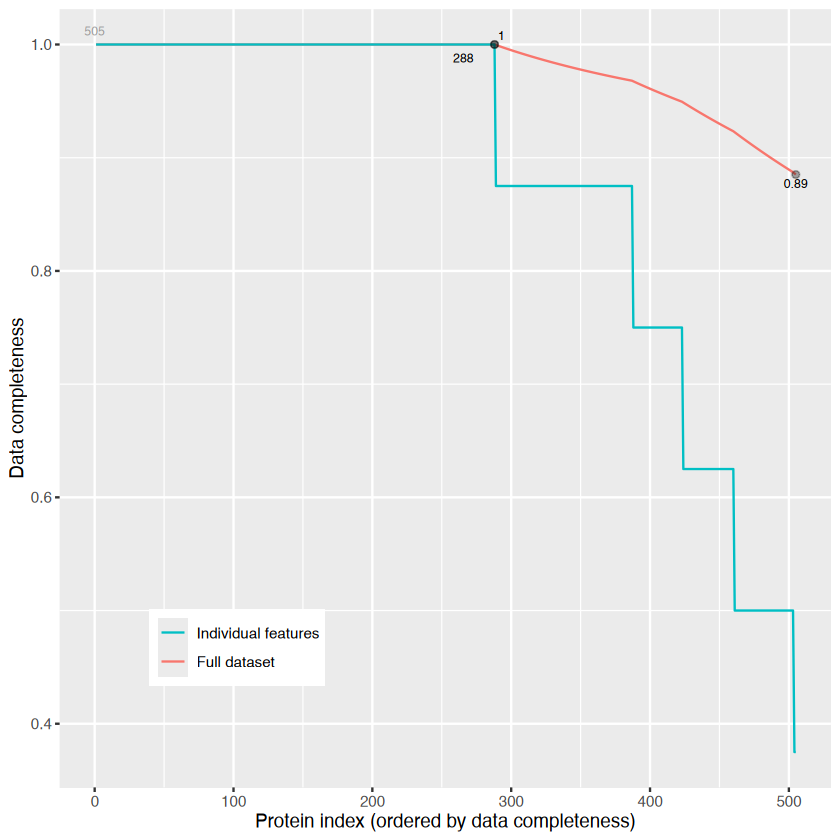

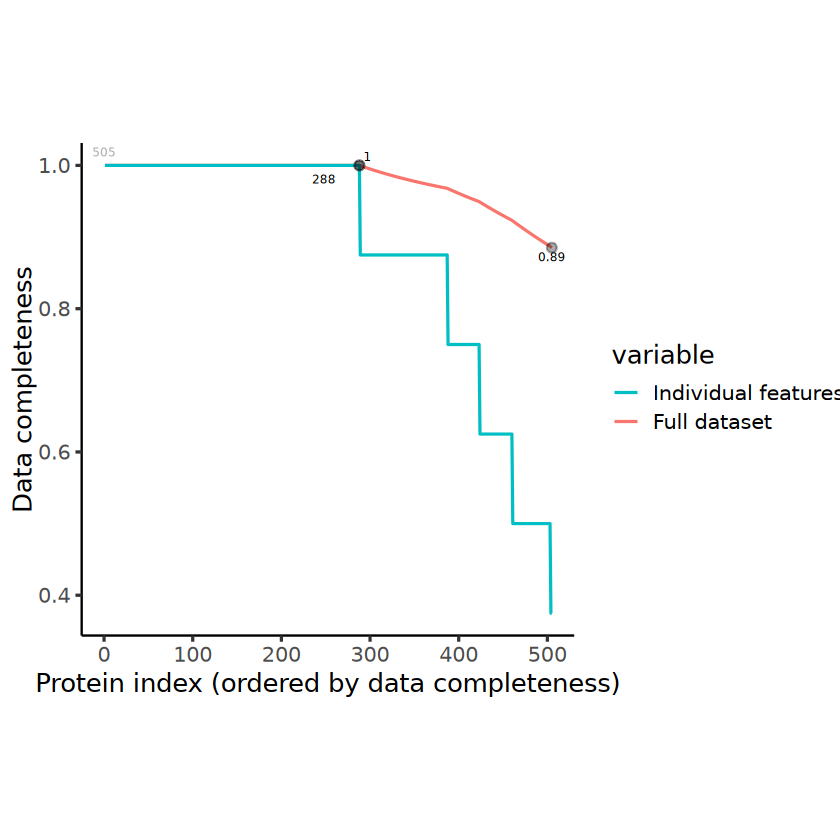

In [27]:
p <- MSnbase::plotNA(prot_robust, pNA = 0) +
  camprotR::theme_camprot(border = FALSE, base_family = 'sans', base_size = 15)
print(p)

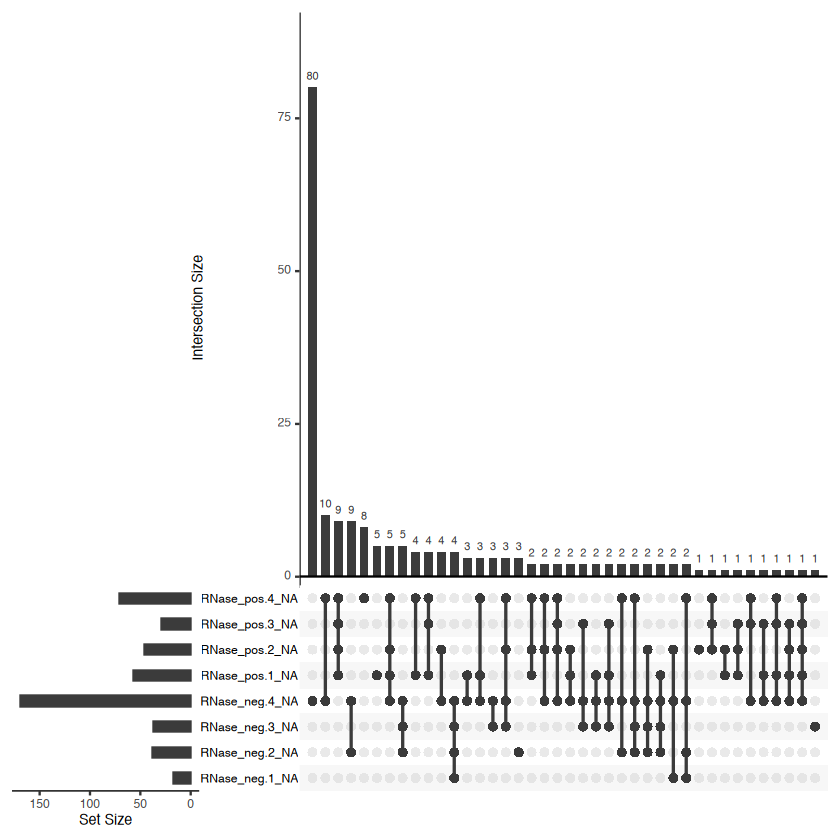

In [28]:
naniar::gg_miss_upset(data.frame(exprs(prot_robust)),
                      sets = paste0(colnames(prot_robust), '_NA'),
                      keep.order = TRUE,
                      nsets = 10)

<div style="font-family:'Times New Roman';">

Ahora hemos procesado nuestras abundancias LFQ a nivel de péptidos y hemos obtenido abundancias a nivel de proteínas, a partir de las cuales podemos realizar nuestros análisis posteriores.

<div style="font-family:'Times New Roman';">

A continuación, guardamos los objetos de nivel de proteína en el disco para poder leerlos en la memoria en análisis posteriores. saveRDSLos guardamos en formato binario R comprimido.

In [29]:
saveRDS(prot_robust, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_prot_robust.rds')


<div style="font-family:'Times New Roman';">

También guardaremos el pep_restricted objeto, ya que se utiliza en Alternativas para resumir la abundancia a nivel de proteína - MaxLFQ

In [30]:
saveRDS(pep_restricted, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_pep_restricted.rds')


<div style="font-family:'Times New Roman';">

**Secciones adicionales opcionales sobre normalización y resumen**

Para una comparación entre robusty maxLFQ para resumir las abundancias a nivel de proteína, consulte el cuaderno **Alternativas para resumir la abundancia a nivel de proteína - MaxLFQ**

Para una demostración de un enfoque de normalización alternativo donde uno tiene una fuerte creencia previa, consulte Normalización a una expectativa previa.

<div style="font-family:'Times New Roman';">

Si bien recomendamos usar el resumen robusto, como se muestra en el cuaderno de procesamiento de datos y control de calidad de LFQ , existen otros algoritmos de aplicación común. Por ejemplo, MaxLFQ (Cox et al., 2014) , implementado en MaxQuant, también está disponible mediante la maxLFQ()función del iq paquete.

Comenzamos leyendo la cuantificación a nivel de péptidos que creamos en el cuaderno de procesamiento de datos y control de calidad de LFQ . Usaremos los mismos péptidos filtrados que usamos para el resumen robusto, de modo que podamos comparar directamente los métodos de resumen.

<div style="font-family:'Times New Roman';">

**Alternativas para resumir la abundancia a nivel de proteínas - MaxLFQ**

In [36]:
library(ggplot2)
library(MSnbase)
library(biobroom)
library(camprotR)
library(Proteomics.analysis.data)
library(dplyr)
library(tidyr)

In [37]:
pep_restricted <- readRDS('/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_pep_restricted.rds')


In [38]:
# You may wish to retain more feature columns that this in your experimental data!
feature_coloumns_to_retain <- c("Master.Protein.Accessions")

pep_data_for_summarisation <- pep_restricted %>%
  exprs() %>%
  data.frame() %>%
  merge(fData(pep_restricted)[, feature_coloumns_to_retain, drop = FALSE], 
        by = 'row.names') %>%
  select(-Row.names)

<div style="font-family:'Times New Roman';">

A continuación, solemos iq::maxLFQ()realizar el resumen manualmente. En teoría, esta función también debería ser posible, MSnbase::combineFeatures()ya que admite funciones definidas por el usuario.

In [39]:
# Define a function to perform MaxLFQ on a single protein and return a data.frame
# as required. 
get_maxlfq_estimate <- function(obj) {
  prot <- iq::maxLFQ(as.matrix(obj))$estimate
  
  data.frame(t(prot)) %>% 
    setNames(colnames(obj))
}

# Group by the features we want to retain and use MaxLFQ on each protein
maxlfq_estimates <- pep_data_for_summarisation %>%
  
  # group by the columns we want to retain. These define a unique protein ID
  group_by(across(all_of(feature_coloumns_to_retain))) %>% 
  
  # Perform maxLFQ summarisation for each group
  dplyr::group_modify(~ get_maxlfq_estimate(.)) %>%
  ungroup()

# Create the protein-level MSnSet
maxlfq.e <- as.matrix(select(maxlfq_estimates, -all_of(feature_coloumns_to_retain)))
maxlfq.f <- data.frame(select(maxlfq_estimates, all_of(feature_coloumns_to_retain)))
maxlfq.p <- pData(pep_restricted)

prot_maxlfq <- MSnSet(exprs = maxlfq.e,
                      fData = maxlfq.f,
                      pData = maxlfq.p)

# Update the rownames to be the protein IDs
rownames(prot_maxlfq) <- maxlfq_estimates$Master.Protein.Accessions

<div style="font-family:'Times New Roman';">

**Comparación de robusta y maxLFQ**

Ahora podemos comparar las estimaciones de abundancia a nivel de proteína. Primero, leemos las estimaciones de abundancia a nivel de proteína que obtuvimos con un resumen robusto.

In [40]:
prot_robust <- readRDS('/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_prot_robust.rds')

<div style="font-family:'Times New Roman';">

Y luego combinamos los resúmenes de los dos enfoques.

In [41]:
# Define a function to extract the protein abundances in long form and
# add a column annotating the method
get_long_form_prot_exp <- function(obj, method_name) {
  tidy(obj) %>%
    rename(abundance=value) %>%
    mutate(method = method_name)
}

# Single object with protein inference from both methods 
compare_protein_abundances <- rbind(
  get_long_form_prot_exp(prot_maxlfq, 'MaxLFQ'),
  get_long_form_prot_exp(prot_robust, 'Robust')
)

<div style="font-family:'Times New Roman';">

Ejercicio

Compare las estimaciones de abundancia de proteínas con "robusto" y "maxLFQ" mediante un diagrama de dispersión (vea el ejemplo a continuación, pero no se preocupe si no coinciden exactamente). ¿Qué conclusión saca?

Sugerencia: Necesitará usar pivot_wider para pivotar los datos de modo que tenga una columna para cada método.

Solución:

#>          Robust   MaxLFQ
#> Robust 1.000000 0.990267
#> MaxLFQ 0.990267 1.000000


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 464 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 464 rows containing missing values or values outside the scale range
(`geom_point()`)."

Adjuntando el paquete: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




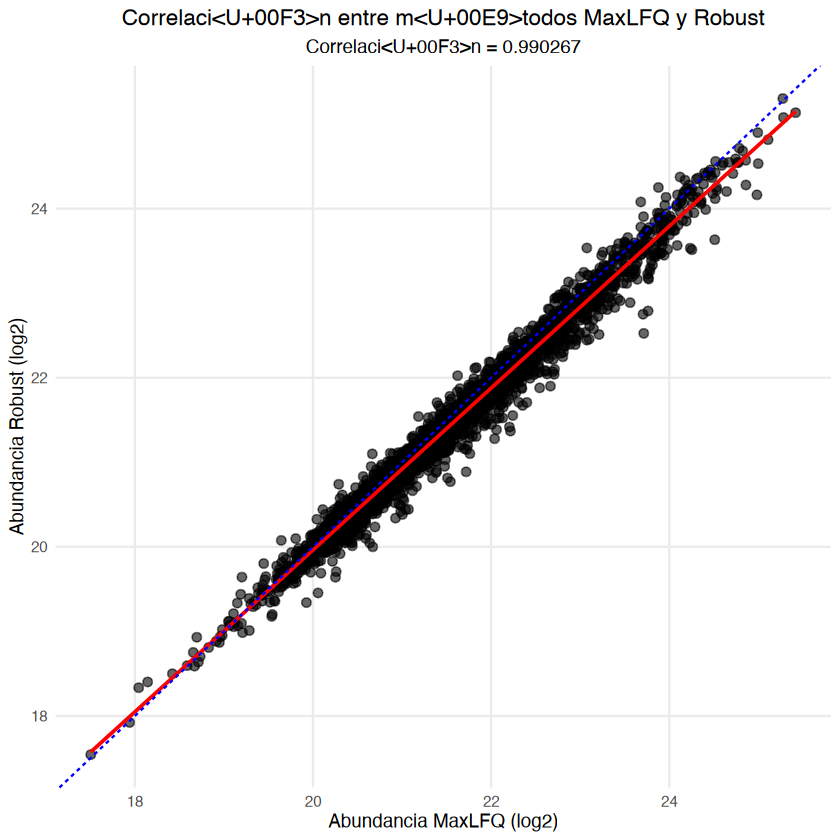

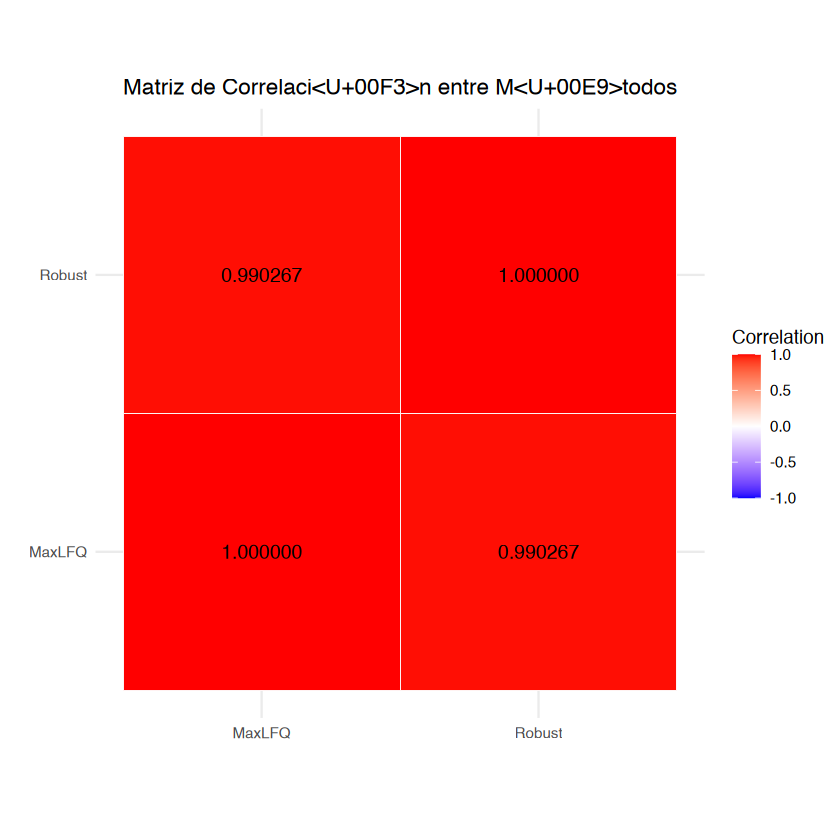

In [42]:
# Cargar librerías necesarias
library(dplyr)
library(tidyr)
library(ggplot2)

# Define a function to extract the protein abundances in long form and
# add a column annotating the method
get_long_form_prot_exp <- function(obj, method_name) {
  suppressWarnings(
    tidy(obj) %>%
      rename(abundance = value) %>%
      mutate(method = method_name),
    classes = "deprecated"
  )
}

# Single object with protein inference from both methods 
compare_protein_abundances <- rbind(
  get_long_form_prot_exp(prot_maxlfq, 'MaxLFQ'),
  get_long_form_prot_exp(prot_robust, 'Robust')
)

# 1. Calcular la matriz de correlación
# Primero convertir los datos a formato ancho para calcular correlaciones
wide_data <- compare_protein_abundances %>%
  pivot_wider(
    names_from = method, 
    values_from = abundance,
    values_fn = mean  # En caso de valores duplicados
  )

# Calcular la matriz de correlación
cor_matrix <- cor(wide_data %>% select(MaxLFQ, Robust), 
                  use = "complete.obs")

# Imprimir la matriz de correlación (formateada como en tu ejemplo)
cat("#>          Robust   MaxLFQ\n")
cat(sprintf("#> Robust %8.6f %8.6f\n", cor_matrix[2,2], cor_matrix[2,1]))
cat(sprintf("#> MaxLFQ %8.6f %8.6f\n", cor_matrix[1,2], cor_matrix[1,1]))

# 2. Crear la visualización (scatter plot con línea de regresión)
ggplot(wide_data, aes(x = MaxLFQ, y = Robust)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "lm", se = FALSE, color = "red", linewidth = 0.8) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "blue", linewidth = 0.5) +
  labs(
    title = "Correlación entre métodos MaxLFQ y Robust",
    subtitle = sprintf("Correlación = %.6f", cor_matrix[1,2]),
    x = "Abundancia MaxLFQ (log2)",
    y = "Abundancia Robust (log2)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5),
    panel.grid.minor = element_blank()
  )

# 3. Opcional: Crear una matriz de correlación visual
# Si quieres mostrar la matriz como heatmap
library(reshape2)

cor_melted <- melt(cor_matrix)
colnames(cor_melted) <- c("Method1", "Method2", "Correlation")

ggplot(cor_melted, aes(x = Method1, y = Method2, fill = Correlation)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.6f", Correlation)), 
            color = "black", size = 4) +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-1, 1), space = "Lab") +
  labs(
    title = "Matriz de Correlación entre Métodos",
    x = "",
    y = ""
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text.x = element_text(angle = 0, vjust = 0.5),
    legend.position = "right"
  ) +
  coord_fixed()

<div style="font-family:'Times New Roman';">

Existe una correlación general muy buena. Analicemos algunas proteínas con las mayores diferencias entre ambos enfoques para ver qué sucede en los casos extremos.

In [43]:
# Identify proteins with largest difference between the protein summarisation methods
proteins_of_interest <- compare_protein_abundances %>%
  pivot_wider(names_from = method, values_from = abundance) %>%
  mutate(diff = MaxLFQ-Robust) %>%
  arrange(desc(abs(diff))) %>%
  pull(protein) %>%
  unique() %>%
  head(5)

<div style="font-family:'Times New Roman';">

A continuación, definimos una función para representar gráficamente las abundancias de péptidos y proteínas de los dos métodos para una sola proteína. Podemos ignorar los detalles, ya que nos interesan los gráficos en sí.

In [44]:
plot_pep_and_protein <- function(protein_of_interest) {
  
  to_plot_compare <- compare_protein_abundances %>% 
    filter(protein == protein_of_interest)
  
  pep_restricted[fData(pep_restricted)$Master.Protein.Accession == protein_of_interest] %>%
    exprs() %>%
    data.frame() %>%
    tibble::rownames_to_column('id') %>%
    pivot_longer(cols = -id) %>%
    ggplot(aes(x = name, y = value)) +
    geom_line(aes(group = id), colour = 'grey', alpha = 0.5) +
    geom_point(colour = 'grey', alpha = 0.5) +
    geom_line(data = to_plot_compare,
              aes(x = sample.id, y = abundance, colour = method, group = method)) +
    geom_point(data = to_plot_compare,
               aes(x = sample.id, y = abundance, colour = method)) +
    scale_colour_manual(values = get_cat_palette(2), name = 'LFQ summarisation method') +
    theme_camprot(base_size = 15, border = FALSE, base_family = 'sans') +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
    labs(
      title = protein_of_interest,
      x = '',
      y = 'Protein abundance (log2)'
    )
}

<div style="font-family:'Times New Roman';">

A continuación, aplicamos la función anterior a cada una de nuestras proteínas de interés.


Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 10 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`)."


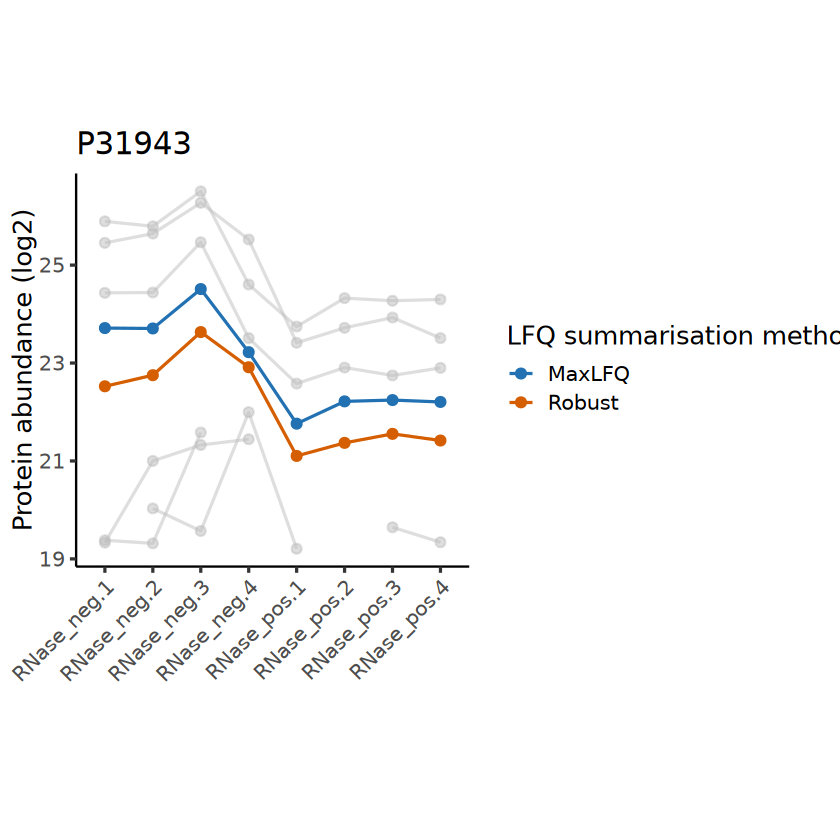

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`)."


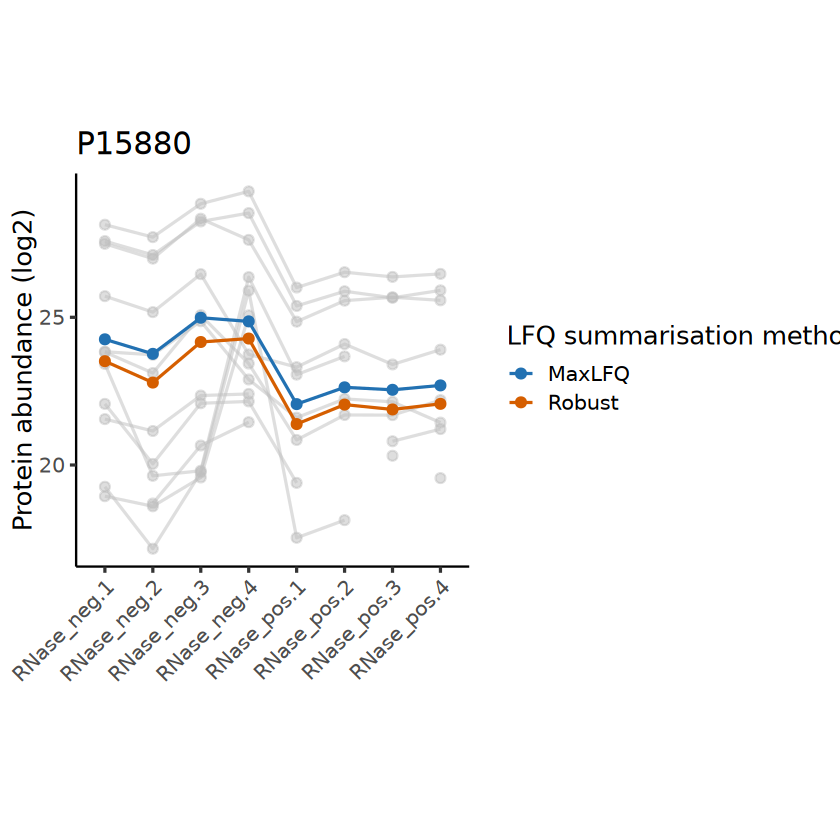

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`)."


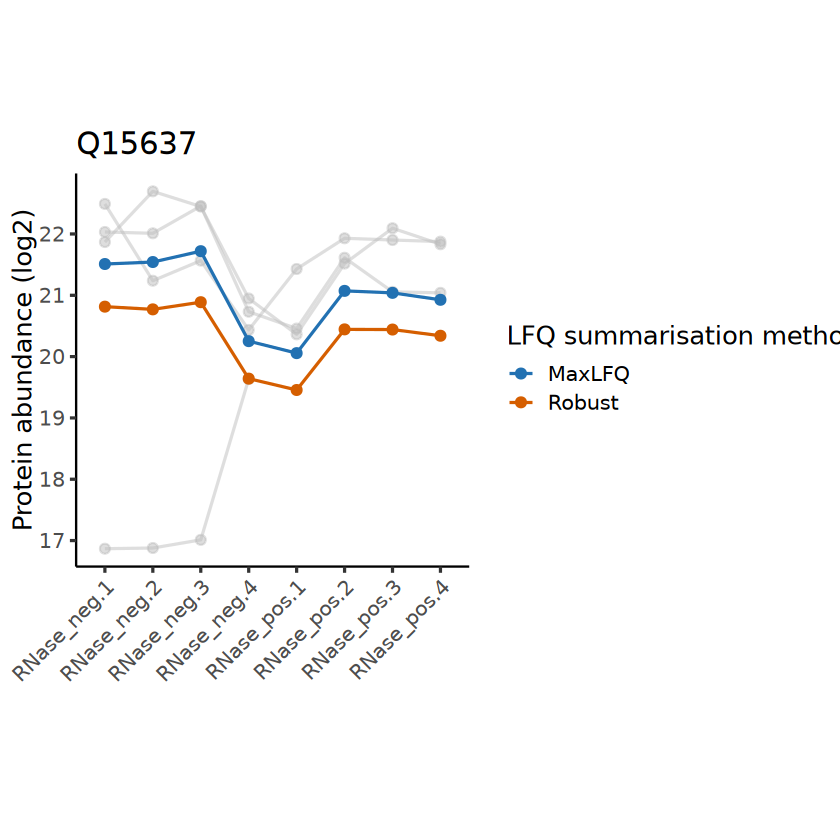

Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`)."


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


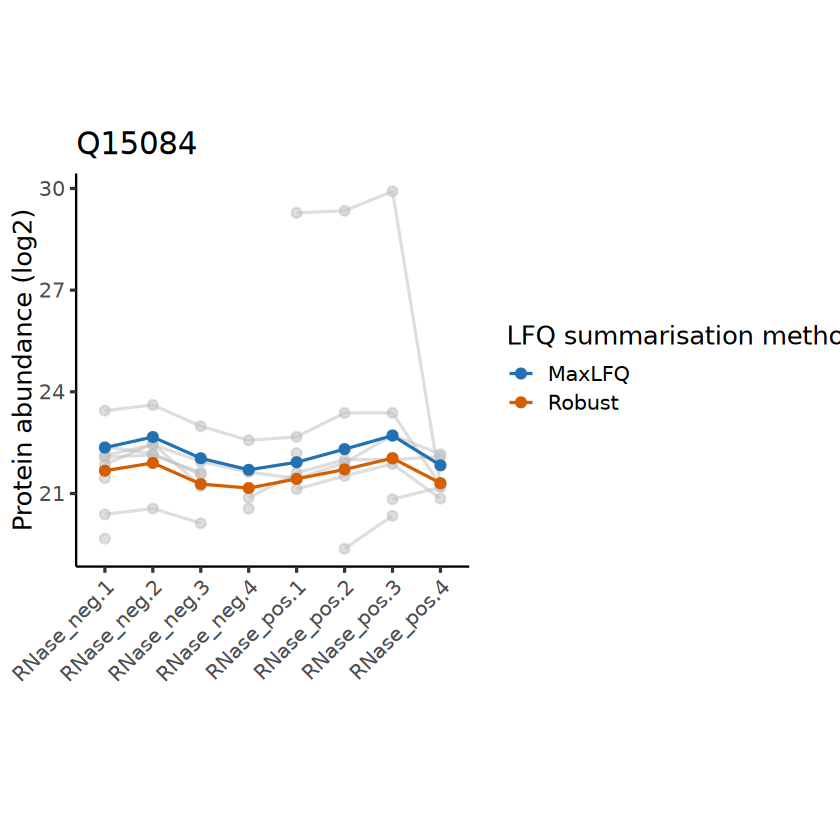

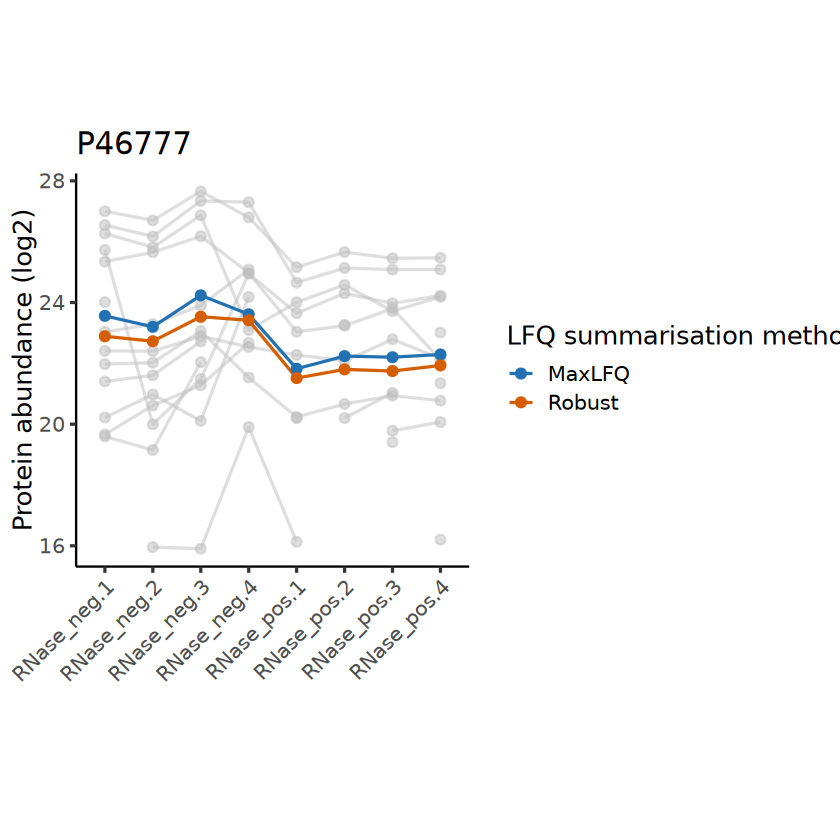

In [45]:
proteins_of_interest %>% lapply(plot_pep_and_protein)


<div style="font-family:'Times New Roman';">

Al observar estos ejemplos, podemos observar que MaxLFQ suele estimar abundancias ligeramente superiores, pero con un perfil muy similar en todas las muestras, por lo que es poco probable que el enfoque de resumen afecte el análisis posterior. No está claro cuál de los dos enfoques es más correcto en los ejemplos anteriores, pero la publicación que propone la inferencia robusta de proteínas (véase aquí ) indica que proporciona estimaciones de cambio de plegamiento más precisas en general.

<div style="font-family:'Times New Roman';">

**Normalización alternativa: uso de proteínas de referencia**

Con la cuantificación sin etiquetas, suele ser adecuado aplicar una normalización simple, como la normalización de "media central" ( diff.medianen MSnbase::normalise) o la normalización de la media recortada de los valores M (TMM). Esto se basa en que la cuantificación debe ser relativa a la cantidad total de proteína en cada muestra.

Hay ocasiones en las que será necesario realizar la normalización a un conjunto de proteínas de referencia, por ejemplo, proteínas endógenas de "mantenimiento" o proteínas exógenas enriquecidas.

Aquí, consideramos otro enfoque de normalización donde tenemos una fuerte expectativa previa sobre la razón de abundancia de un subconjunto de proteínas entre dos condiciones. Nuestros datos provienen del cuaderno de procesamiento de datos y control de calidad LFQ . Consulte el cuaderno anterior para obtener una explicación del experimento. El punto importante es que se sabe que OOPS enriquece las glicoproteínas en la interfaz. Por lo tanto, podemos usar estas proteínas como un conjunto interno de proteínas de referencia que esperamos que no presenten diferencias en abundancia entre la ARNasa +/-.

Dependencias de carga

Cargue las bibliotecas necesarias.

In [46]:
library(ggplot2)
library(MSnbase)
library(biobroom)
library(camprotR)
library(Proteomics.analysis.data)
library(dplyr)
library(tidyr)
library(uniprotREST)

<div style="font-family:'Times New Roman';">

Cargar datos

Comenzamos leyendo la cuantificación a nivel de proteína que creamos en el cuaderno de procesamiento de datos y control de calidad de LFQ.

In [47]:
prot_robust <- readRDS('/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_prot_robust.rds')


<div style="font-family:'Times New Roman';">

Primero, necesitamos calcular las relaciones RNasa +/-, ya que este es el valor que queremos normalizar en este caso.



In [48]:
ratios <- exprs(prot_robust[,pData(prot_robust)$Condition == 'RNase_neg']) - 
  exprs(prot_robust[,pData(prot_robust)$Condition == 'RNase_pos'])

prot_ratios <- MSnSet(exprs = ratios,
                      fData = fData(prot_robust),
                      pData = (pData(prot_robust) %>% filter(Condition == 'RNase_neg')))

<div style="font-family:'Times New Roman';">

Obtenga anotaciones para glicoproteínas y unión de ARN GO-'

A continuación, necesitamos anotaciones sobre qué proteínas son glicoproteínas y RBP anotadas por GO.

Aquí, consultamos a UniProt mediante programación para obtener los términos y características GO de nuestras proteínas, que analizaremos más a fondo para determinar las GO-RBP y las glicoproteínas.

In [49]:
glyco_res <-  uniprot_map(
  ids = rownames(prot_robust),
  from = "UniProtKB_AC-ID",
  to = "UniProtKB",
  fields = "ft_carbohyd",
) %>% rename(c('UNIPROTKB'='From'))
#> Job ID: 78e84369fd78a8e63608de318ef34d83919d3a18

go_res <-  uniprot_map(
  ids = rownames(prot_robust),
  from = "UniProtKB_AC-ID",
  to = "UniProtKB",
  fields = "go",
) %>% rename(c('UNIPROTKB'='From'))

Running job: jZmNXmPGo7 
Checking job status...


Waiting 3s for retry backoff ===========>------------------- 

Waiting 3s for retry backoff ==============================> 



Job complete!
 Downloading: page 2 of 2Running job: jZmNXmPGo7 
Checking job status...
Job complete!
 Downloading: page 2 of 2

<div style="font-family:'Times New Roman';">

Obtenga las GO-RBP. Tenga en cuenta que también identificamos proteínas anotadas con descendientes del término GO de unión al ARN, ya que algunas proteínas solo se anotarán con el término hijo.



In [50]:
# GO term for RNA-binding
go_rbp <- "GO:0003723"

# All offspring (since some proteins will only be annotated with an offspring term)
go_rbp_offspring <- AnnotationDbi::get("GO:0003723", GO.db::GOMFOFFSPRING)
#> 

# Identify all GO-RBPs
rbps <- go_res %>%
  separate_rows(Gene.Ontology..GO., sep='; ') %>%
  mutate(go=gsub('.*\\[(\\S+)\\]', '\\1', Gene.Ontology..GO.)) %>%
  filter(go %in% c(go_rbp, go_rbp_offspring)) %>% 
  pull(UNIPROTKB) %>%
  unique()

<div style="font-family:'Times New Roman';">

Obtenga las glicoproteínas. Tenga en cuenta que solo conservamos las proteínas con al menos tres sitios glicosilados para garantizar la seguridad de su glicosilación.

In [51]:
glycoproteins <- glyco_res %>% 
  # remove proteins with empty glycoprotein annotation
  filter(Glycosylation!='') %>%
  # separate the glycoprotein annotation into constituent parts
  separate_rows(Glycosylation, sep = "; ") %>%
  # keep the annotations relating to glycosylated position
  filter(grepl("CARBOHYD", Glycosylation)) %>%
  # count the number of glycosylated sites per protein
  group_by(UNIPROTKB) %>%  tally() %>%
  # keep proteins with 3 or more glycosylations
  filter(n>=3) %>%
  pull(UNIPROTKB)

<div style="font-family:'Times New Roman';">

Agregue columnas de características que describan el estado de glicoproteína y GO-RBP de las proteínas.



In [52]:
fData(prot_ratios) <- fData(prot_ratios) %>%
  mutate(Glycoprotein = rownames(prot_ratios) %in% glycoproteins) %>%
  mutate(GO.RBP = rownames(prot_ratios) %in% rbps) %>%
  mutate(Glyco.RBP = interaction(Glycoprotein, GO.RBP)) %>%
  mutate(Glyco.RBP = factor(recode(
    Glyco.RBP,
    'TRUE.TRUE'='GO:RBGP',
    'FALSE.TRUE'='GO:RBP',
    'TRUE.FALSE'='Glycoprotein',
    'FALSE.FALSE'='Other'),
    levels = c('GO:RBP', 'GO:RBGP', 'Other', 'Glycoprotein'))
  )


<div style="font-family:'Times New Roman';">

Finalmente, definimos una función para graficar las proporciones para cada subtipo funcional de proteínas.



In [53]:
plot_ratios <- function(obj) {
  to_plot <- merge(
    exprs(obj),
    fData(obj)[,'Glyco.RBP',drop = FALSE],
    by = 'row.names'
  ) %>%
    pivot_longer(cols = -c(Row.names, Glyco.RBP), names_to = 'sample', values_to = 'ratio') %>%
    merge(pData(obj), by.x = 'sample', by.y = 'row.names') %>%
    filter(is.finite(ratio))
  
  p <- to_plot %>% 
    ggplot(aes(x = Replicate, y = ratio, 
               group = interaction(Glyco.RBP, Replicate), 
               colour = factor(Glyco.RBP))) +
    geom_boxplot(position = position_dodge()) +
    theme_camprot(border = FALSE, base_family = 'sans', base_size = 15) +
    scale_colour_manual(values = c(get_cat_palette(3), 'black'), name = '') +
    geom_hline(yintercept = 0, linetype = 2, colour = 'grey') +
    labs(
      x = "Replicate",
      y = "RNase -/+ ratio"
    )
  
  print(p)
  
  invisible(to_plot)
}


<div style="font-family:'Times New Roman';">

Normalización frente a las glicoproteínas

Ahora que tenemos todo en su lugar, podemos ver cómo se ven las proporciones de proteínas antes de la normalización...



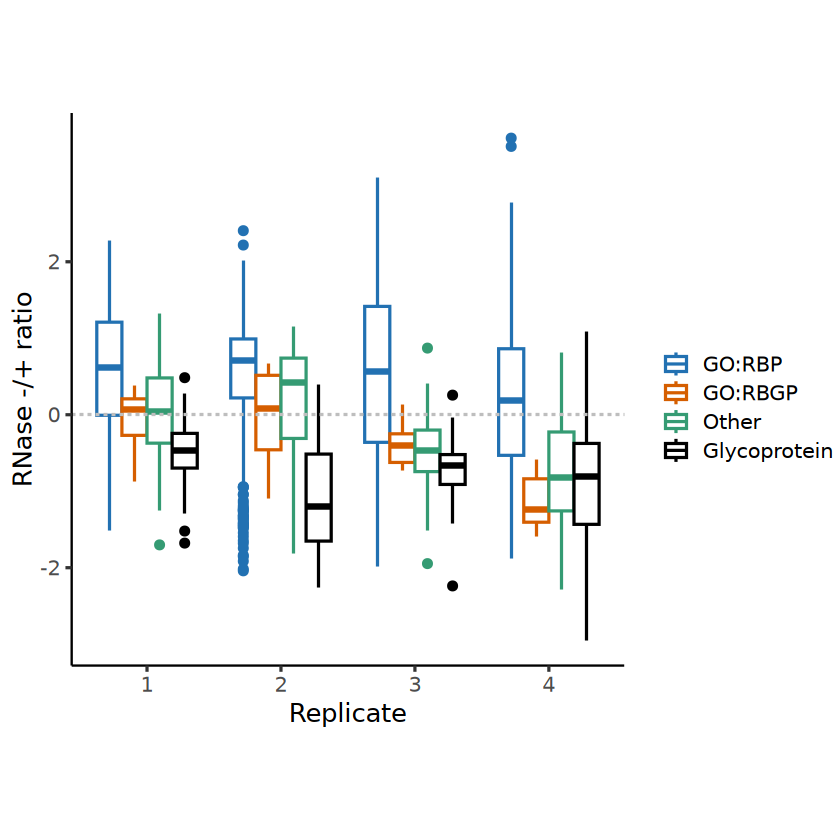

In [54]:
plot_ratios(prot_ratios)


<div style="font-family:'Times New Roman';">
Bien, entonces las glicoproteínas no están centradas en cero y hay RBP anotadas por GO con relaciones logarítmicas RNasa -/+ negativas (hasta un ~25 % en la réplica 2).

A continuación, realizamos la normalización centro-mediana con respecto a las proteínas de referencia (aquí, las glicoproteínas).



In [55]:
glycoprotein_medians <- prot_ratios[fData(prot_ratios)$Glyco.RBP == 'Glycoprotein',] %>% 
  camprotR::get_medians()

prot_ratios_norm <- camprotR::center_normalise_to_ref(
  prot_ratios,
  glycoprotein_medians,
  center_to_zero = TRUE, # We want to center the glycoproteins around zero
  on_log_scale = TRUE # The quantifications are on a log scale (log2 ratios)
)

<div style="font-family:'Times New Roman';">

Y graficar las proporciones de proteínas después de la normalización.



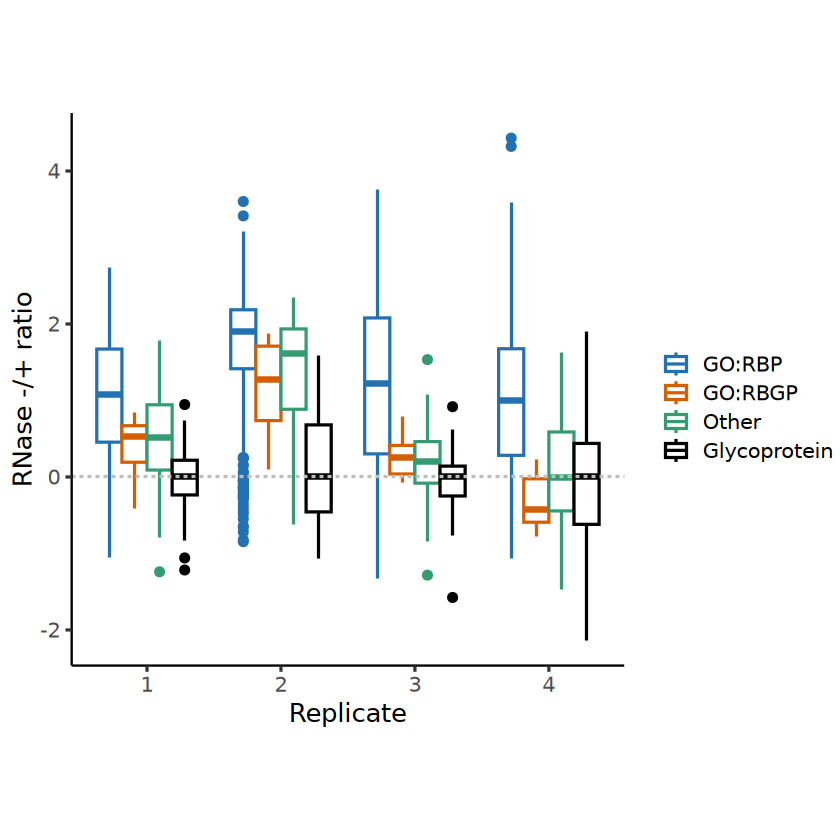

In [56]:
plot_ratios(prot_ratios_norm)


In [57]:
saveRDS(prot_ratios_norm, '/Volumes/alex/BS_scripts_clase/proteomics-data-analysis-tutorial-master/lfq_prot_robust_glyco_norm.rds')


<div style="font-family:'Times New Roman';">

Ahora, la relación media log2 RNasa -/+ para las glicoproteínas es cero para todas las réplicas y tenemos muchos menos RBP anotados con GO con relaciones log2 RNasa -/+ negativas.